In [1]:
# Install (run only once if not installed)
!pip install datasets transformers torch scikit-learn matplotlib seaborn tqdm

In [2]:
#Imports
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, AdamW
from torch.utils.data import DataLoader
from tqdm import tqdm
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

/Users/shivrajsinghbhati/anaconda3/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/shivrajsinghbhati/anaconda3/lib/python3.10/site-packages/google/api_core/_python_version_support.py:273: FutureWarning: You are using a Python version (3.10.9) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


In [4]:
#Project paths
PROJECT_ROOT = "/Users/shivrajsinghbhati/Desktop/bert-multiclass-news-classification"

MODEL_SAVE_PATH = os.path.join(PROJECT_ROOT, "saved_model", "bert_ag_news")
PLOTS_PATH = os.path.join(PROJECT_ROOT, "outputs", "plots")

os.makedirs(MODEL_SAVE_PATH, exist_ok=True)
os.makedirs(PLOTS_PATH, exist_ok=True)

In [5]:
#Loading Datasets
dataset = load_dataset("ag_news")
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})

In [6]:
#Labels
label_names = dataset["train"].features["label"].names
label_names

['World', 'Sports', 'Business', 'Sci/Tech']

In [7]:
#Inspecting sample
dataset["train"][0]

{'text': "Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\\band of ultra-cynics, are seeing green again.",
 'label': 2}

In [8]:
#Load BERT Tokenizer
MODEL_NAME = "bert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

/Users/shivrajsinghbhati/anaconda3/lib/python3.10/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [9]:
#Tokenization Function
MAX_LENGTH = 128

def tokenize_function(example):
    return tokenizer(
        example["text"],
        padding="max_length",
        truncation=True,
        max_length=MAX_LENGTH
    )

In [10]:
#Tokenizing Dataset
tokenized_dataset = dataset.map(tokenize_function, batched=True)
tokenized_dataset = tokenized_dataset.remove_columns(["text"])
tokenized_dataset.set_format("torch")

tokenized_dataset

Map: 100%|████████████████████████| 7600/7600 [00:00<00:00, 28182.72 examples/s]


DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 7600
    })
})

In [11]:
#Reducing Dataset
train_dataset = tokenized_dataset["train"].select(range(2000))
test_dataset = tokenized_dataset["test"].select(range(500))

len(train_dataset), len(test_dataset)

(2000, 500)

In [12]:
#Data Loader
BATCH_SIZE = 16

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

In [13]:
#Loading BERT Model
NUM_LABELS = 4

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS
)

Some weights of the model checkpoint at bert-base-uncased were not used when initializing BertForSequenceClassification: ['cls.predictions.transform.dense.weight', 'cls.seq_relationship.bias', 'cls.predictions.transform.dense.bias', 'cls.predictions.decoder.weight', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.bias', 'cls.predictions.transform.LayerNorm.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at

In [14]:
#Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

device

device(type='cpu')

In [15]:
#optimizer
optimizer = AdamW(model.parameters(), lr=2e-5)

/Users/shivrajsinghbhati/anaconda3/lib/python3.10/site-packages/transformers/optimization.py:306: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


In [16]:
#Training loop, 3 epochs
EPOCHS = 3

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    loop = tqdm(train_loader, leave=True)

    for batch in loop:
        optimizer.zero_grad()

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        total_loss += loss.item()

        loss.backward()
        optimizer.step()

        loop.set_description(f"Epoch {epoch + 1}/{EPOCHS}")
        loop.set_postfix(loss=loss.item())

    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch + 1} Average Loss: {avg_loss:.4f}")

Epoch 1/3: 100%|██████████████████| 125/125 [29:48<00:00, 14.31s/it, loss=0.158]


Epoch 1 Average Loss: 0.6923


Epoch 2/3: 100%|███████████████████| 125/125 [38:50<00:00, 18.65s/it, loss=0.36]


Epoch 2 Average Loss: 0.2665


Epoch 3/3: 100%|██████████████████| 125/125 [29:43<00:00, 14.27s/it, loss=0.197]

Epoch 3 Average Loss: 0.1388


In [17]:
#Evaluation
model.eval()

predictions = []
true_labels = []

with torch.no_grad():
    for batch in tqdm(test_loader):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        logits = outputs.logits
        preds = torch.argmax(logits, dim=1)

        predictions.extend(preds.cpu().numpy())
        true_labels.extend(labels.cpu().numpy())

100%|███████████████████████████████████████████| 32/32 [01:52<00:00,  3.50s/it]


In [19]:
#Metrics
accuracy = accuracy_score(true_labels, predictions)

print(f"Accuracy: {accuracy:.4f}")
print("\nClassification Report:\n")
print(classification_report(true_labels, predictions, target_names=label_names))

Accuracy: 0.8800

Classification Report:

              precision    recall  f1-score   support

       World       0.80      0.93      0.86       122
      Sports       0.99      0.87      0.93       145
    Business       0.90      0.75      0.82       106
    Sci/Tech       0.85      0.95      0.90       127

    accuracy                           0.88       500
   macro avg       0.88      0.88      0.88       500
weighted avg       0.89      0.88      0.88       500



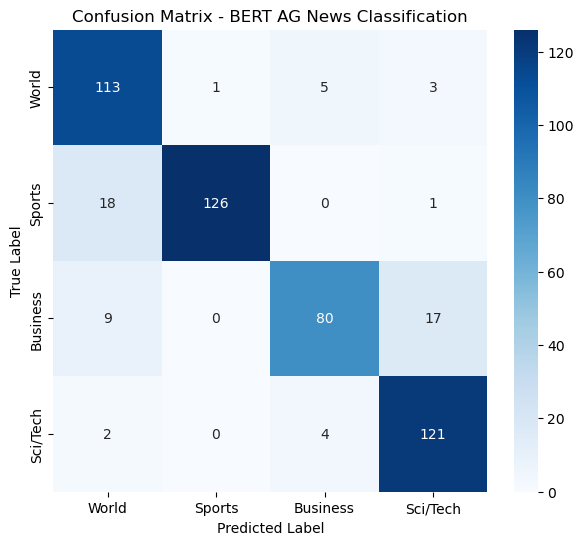

Confusion matrix saved at: /Users/shivrajsinghbhati/Desktop/bert-multiclass-news-classification/outputs/plots/confusion_matrix.png


In [20]:
#Confusing Metrix
cm = confusion_matrix(true_labels, predictions)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_names,
    yticklabels=label_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - BERT AG News Classification")

save_path = os.path.join(PLOTS_PATH, "confusion_matrix.png")
plt.savefig(save_path, bbox_inches="tight", dpi=300)

plt.show()

print("Confusion matrix saved at:", save_path)

In [21]:
#Saving model and Tokenizer
model.save_pretrained(MODEL_SAVE_PATH)
tokenizer.save_pretrained(MODEL_SAVE_PATH)

print("Model and tokenizer saved successfully at:")
print(MODEL_SAVE_PATH)

Model and tokenizer saved successfully at:
/Users/shivrajsinghbhati/Desktop/bert-multiclass-news-classification/saved_model/bert_ag_news


In [22]:
#Prediction Function
def predict_news_category(text):
    inputs = tokenizer(
        text,
        padding="max_length",
        truncation=True,
        max_length=MAX_LENGTH,
        return_tensors="pt"
    )

    input_ids = inputs["input_ids"].to(device)
    attention_mask = inputs["attention_mask"].to(device)

    model.eval()

    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        predicted_class = torch.argmax(outputs.logits, dim=1).item()

    return label_names[predicted_class]

In [23]:
#Test predictions
examples = [
    "The prime minister met foreign leaders to discuss climate policy.",
    "India defeated Australia in the final cricket match.",
    "Stock markets rose after strong quarterly earnings reports.",
    "NASA announced a new mission to study Mars."
]

for text in examples:
    print("Text:", text)
    print("Prediction:", predict_news_category(text))
    print("-" * 60)

Text: The prime minister met foreign leaders to discuss climate policy.
Prediction: World
------------------------------------------------------------
Text: India defeated Australia in the final cricket match.
Prediction: World
------------------------------------------------------------
Text: Stock markets rose after strong quarterly earnings reports.
Prediction: Business
------------------------------------------------------------
Text: NASA announced a new mission to study Mars.
Prediction: Sci/Tech
------------------------------------------------------------
